<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session19: SVM | Part01</font></h3>
<h3 align="center">Zahra Amini</h3>

# SVM

## Margin in SVM
<br>
<br>
<br>

![Margin in SVM](https://static.wixstatic.com/media/8f929f_7ecacdcf69d2450087cb4a898ef90837~mv2.png)

<br>
<br>
<br>
<br>
<br>
<br>

![Maximum margin hyperplane](https://static.packt-cdn.com/products/9781783555130/graphics/3547_03_07.jpg)

<br>
<br>
<br>
<br>
<br>
<br>

## Kernel trick - transformation of input space to higher dimensional space
<br>
<br>
<br>


![Kernel trick](http://www.aionlinecourse.com/uploads/tutorials/2019/07/11_21_kernel_svm_3.png)

## SVM Kernel

### Kernel:  {‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}  ---> default=’rbf’


## Polynomial Kernel

![Polynomial Kernel](https://www.researchgate.net/profile/Cheng_Soon_Ong/publication/23442384/figure/fig12/AS:341444054274063@1458418014823/The-effect-of-the-degree-of-a-polynomial-kernel-The-polynomial-kernel-of-degree-1-leads.png)

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from sklearn import svm

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data1.csv')

In [3]:
df

,x1,x2,target
0,1.70,11.10,0
1,3.77,22.96,1
2,3.35,14.08,1
3,1.90,10.40,0
4,1.61,22.98,1
...,...,...,...
295,1.50,21.44,1
296,4.57,22.80,1
297,1.00,8.80,0
298,2.27,22.21,1


In [4]:
X = df.drop('target', axis=1)

y = df['target']

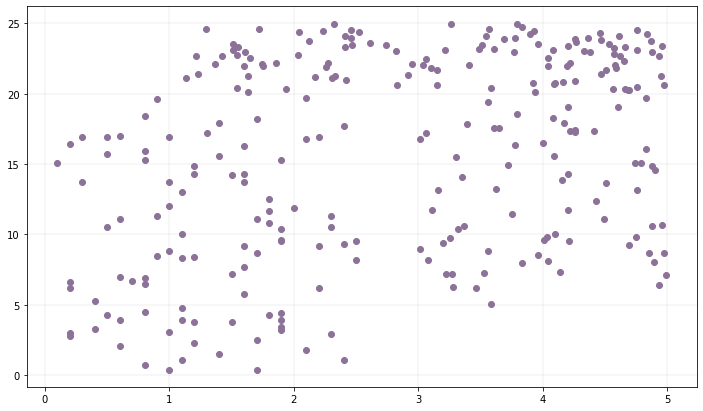

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Plotting the training set
fig, ax = plt.subplots(figsize=(12, 7))

ax.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)
ax.scatter(X_train['x1'], X_train['x2'], color="#8C7298")
plt.show()

# Linear Kernel

In [6]:
linear_model = svm.SVC(kernel='linear')
linear_model.fit(X_train, y_train)

SVC(kernel='linear')

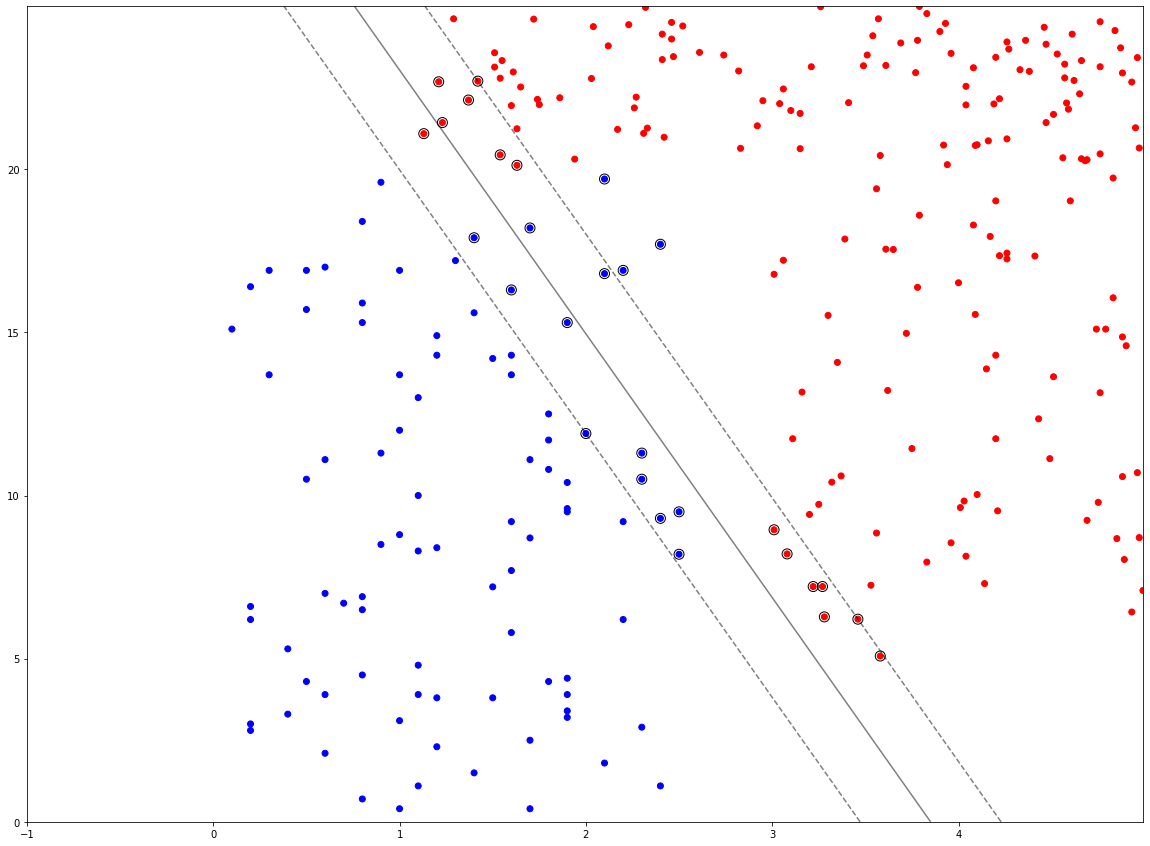

In [7]:
fig, ax = plt.subplots(figsize=(20, 15))
c=5

xx = np.linspace(-1, max(X_train['x1']), len(X_train))
yy = np.linspace(0, max(X_train['x2']), len(y_train))
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
train_size = len(X_train['x1'])


colors = np.where(y_train == 1, 'red', 'b')
    

ax.scatter(X_train['x1'], X_train['x2'], c=colors)
    

Z = linear_model.decision_function(xy).reshape(XX.shape)
    

c=linear_model.C
ax.contour(XX, YY, Z, colors='k', levels=[-c, 0, c], alpha=0.5, linestyles=['--', '-', '--'])
    

ax.scatter(linear_model.support_vectors_[:, 0], linear_model.support_vectors_[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [8]:
predictions_lin = linear_model.predict(X_test)
accuracy_lin = accuracy_score(y_test, predictions_lin)
accuracy_lin

0.9333333333333333

# Poly Kernel

In [9]:
SVM_model = svm.SVC(C=2, kernel='poly', degree=10)
SVM_model.fit(X_train, y_train)

SVC(C=2, degree=10, kernel='poly')

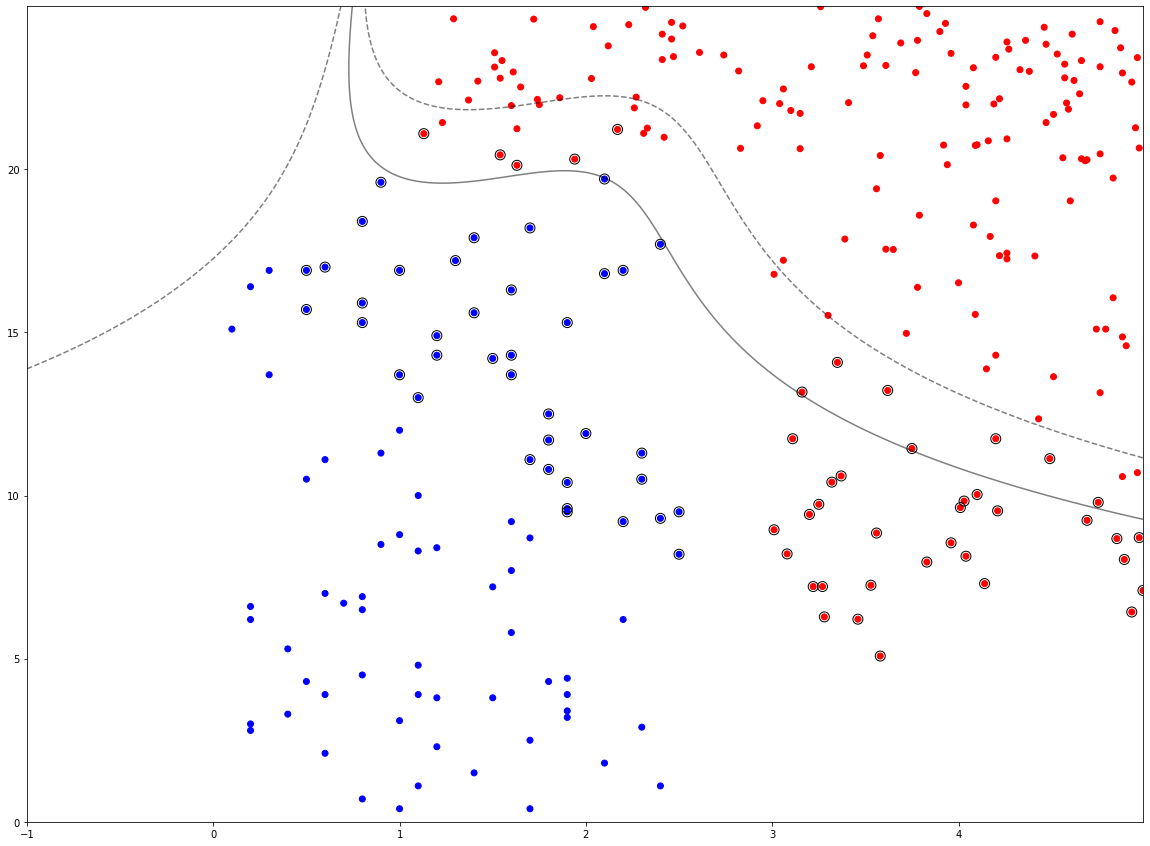

In [10]:
fig, ax = plt.subplots(figsize=(20, 15))
c=5

xx = np.linspace(-1, max(X_train['x1']), len(X_train))
yy = np.linspace(0, max(X_train['x2']), len(y_train))
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
train_size = len(X_train['x1'])


colors = np.where(y_train == 1, 'red', 'b')
    

ax.scatter(X_train['x1'], X_train['x2'], c=colors)
    

Z = SVM_model.decision_function(xy).reshape(XX.shape)
    

c=SVM_model.C
ax.contour(XX, YY, Z, colors='k', levels=[-c, 0, c], alpha=0.5, linestyles=['--', '-', '--'])
    

ax.scatter(SVM_model.support_vectors_[:, 0], SVM_model.support_vectors_[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [11]:
predictions_poly = SVM_model.predict(X_test)
accuracy_poly = accuracy_score(y_test, predictions_poly)
print("2nd degree polynomial Kernel\nAccuracy (normalized): " + str(accuracy_poly))

2nd degree polynomial Kernel
Accuracy (normalized): 0.8666666666666667


# Finished!